# Probability distributions and simulation

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/foundations/03-variability-and-inference.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

Engineers use probability distributions to describe quantities that vary: a manufacturing dimension, a load, a sensor reading, or an emission measurement. In this notebook, you will use NumPy to simulate and visualize a few common distributions.

This is preparation for our in-class discussion of the central limit theorem (CLT). We will discuss sampling distributions, formal hypothesis tests, and p-values together in class.

**Learning objectives**

- Draw random samples from normal, uniform, and exponential distributions with NumPy.
- Use histograms to compare the shapes of simulated distributions.
- Calculate and interpret a sample mean and standard deviation.
- Relate a distribution to both a familiar situation and a possible engineering application.

## 1. Set up a simulation

A simulation creates artificial observations according to rules we specify. This lets us isolate one statistical idea at a time before working with messier engineering measurements.

In [1]:
# NumPy generates random samples; Matplotlib displays them.
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
# A fixed seed makes the examples reproducible: everyone sees the same draw.
rng = np.random.default_rng(4520)

## 2. Draw samples from probability distributions

A **distribution** describes the values a variable can take and how frequently different values occur. We will begin with three useful distribution shapes. These are useful approximations, not automatic labels for every engineering variable: choosing a distribution should be guided by the physical mechanism and by observed data.

### Normal distribution

A normal distribution is symmetric around a typical value and is often useful when many small, independent sources of variation add together. A familiar example is adult height within a relatively homogeneous population. An engineering example is repeated measurements of a machined part's diameter when the process is stable.

`rng.normal(loc, scale, size)` draws `size` observations with mean `loc` and standard deviation `scale`.
2. 从概率分布中抽取样本

分布描述了变量可以取的值以及不同值出现的频率。我们将从三种常用的分布形状开始。这些是有用的近似值，并非每个工程变量的通用标签：选择分布应根据物理机制和观测数据来决定。

正态分布

正态分布围绕一个典型值对称，当许多小的、独立的变异源叠加在一起时，正态分布通常很有用。一个常见的例子是相对同质人群中成年人的身高。一个工程例子是加工过程稳定时对加工零件直径的重复测量。

`rng.normal(loc, scale, size)` 以 `loc` 为均值，`scale` 为标准差，抽取尺寸观测值。

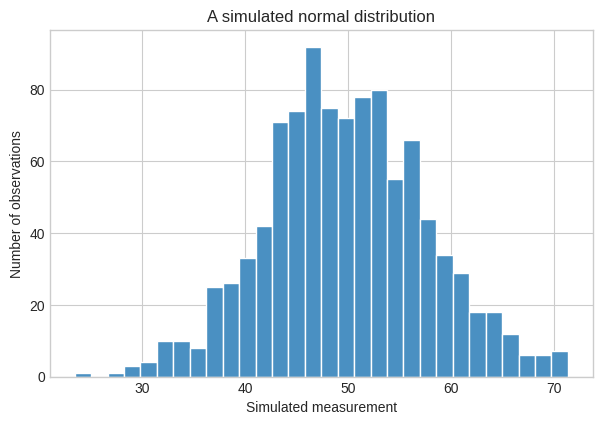

Sample mean: 49.76
Sample standard deviation: 7.84


In [2]:
# Simulate 1,000 measurements centered at 50 with a spread of 8.
normal_sample = rng.normal(loc=50, scale=8, size=1_000)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(normal_sample, bins=30, color="#4a90c2", edgecolor="white")
ax.set(
    xlabel="Simulated measurement",
    ylabel="Number of observations",
    title="A simulated normal distribution",
)
plt.show()

print(f"Sample mean: {normal_sample.mean():.2f}")
print(f"Sample standard deviation: {normal_sample.std(ddof=1):.2f}")
#ddof=1（Delta Degrees of Freedom）：设置自由度修正值为 1。在统计推断中，分母使用 $n-1$（即 $n - \text{ddof}$）才能对总体的标准差做出无偏估计；若不加则默认 $n$，会低估标准差。

### Try it

Draw a normal sample centered at 100 with a standard deviation of 15. How do its histogram and sample summary differ from the one above?

In [3]:
# my_sample = rng.normal(loc=..., scale=..., size=...)
# print(my_sample.mean())
# print(my_sample.std(ddof=1))

### Uniform distribution

In a uniform distribution, every value in an interval is equally likely. A familiar example is an ideal random-number generator that returns any number from 0 to 1. An engineering simulation might choose an initial shaft angle at random between two limits, or sample evenly across an allowable tolerance range.

`rng.uniform(low, high, size)` draws values evenly between two limits. Unlike the normal distribution, it has no single central value that is more likely than another within that interval.
均匀分布

在均匀分布中，区间内的每个值出现的概率均等。一个常见的例子是理想随机数生成器，它会返回 0 到 1 之间的任意数字。工程仿真可能会在两个限值之间随机选择一个初始轴角，或者在允许的公差范围内均匀采样。

`rng.uniform(low, high, size)` 会在两个限值之间均匀抽取值。与正态分布不同，均匀分布中不存在某个中心值比其他值出现的概率更高的情况。

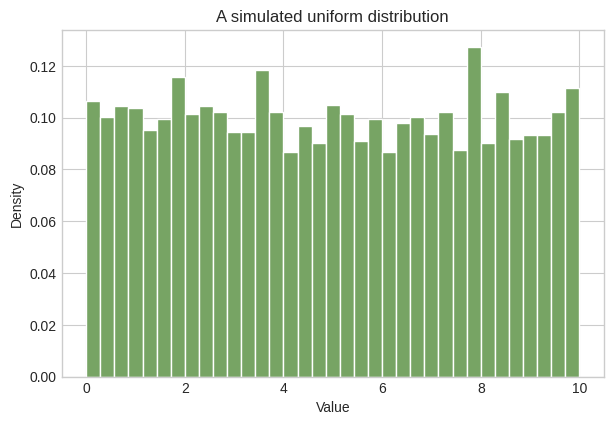

In [6]:
# Draw 5,000 values with equal probability anywhere from 0 to 10.
uniform = rng.uniform(low=0, high=10, size=5_000)
#rng.uniform(...)：生成在指定区间内等概率出现的连续随机数。low=0, high=10：定义数值区间为 $[0, 10)$。size=5_000：抽样数量为 5,000 个数据点。
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(uniform, bins=35, density=True, color="#77a464", edgecolor="white")
#bins=35：将 0 到 10 的区间划分为 35 个等宽子区间。density=True（核心参数）：将纵轴从传统的“频数/计数（Count）”归一化转化为“概率密度（Density）”，使所有柱体归一化后的总面积等于 $1$。对于区间 $[0, 10]$ 的均匀分布，理论密度高度应恒为 $\frac{1}{10-0} = 0.1$。color="#77a464"：使用绿色柱体填充。
ax.set(title="A simulated uniform distribution", xlabel="Value", ylabel="Density")
plt.show()

### Exponential distribution

An exponential distribution is nonnegative and right-skewed, so it is often used to model waiting times. A familiar example is the waiting time until the next customer arrives when arrivals occur independently at a roughly constant average rate. In engineering, it can model the lifetime of one component when its instantaneous failure rate is assumed constant: a component that has already operated for 10 hours is, under this simplified model, no more or less likely to fail in the next hour than a new one.

`rng.exponential(scale, size)` draws nonnegative, right-skewed values. Its average is approximately `scale`; most draws are relatively small, but occasionally a much larger value occurs.
指数分布

指数分布是非负且右偏的，因此常用于模拟等待时间。一个常见的例子是，当顾客以大致恒定的平均速率独立到达时，等待下一个顾客到达的时间。在工程学中，它可以模拟单个组件的寿命，假设其瞬时故障率恒定：在这个简化的模型下，一个已经运行了 10 小时的组件在接下来的一个小时内发生故障的概率与一个新组件相同。

`rng.exponential(scale, size)` 会生成非负的右偏值。它的平均值近似等于 `scale`；大多数值都相对较小，但偶尔也会出现远大于此值的情况。

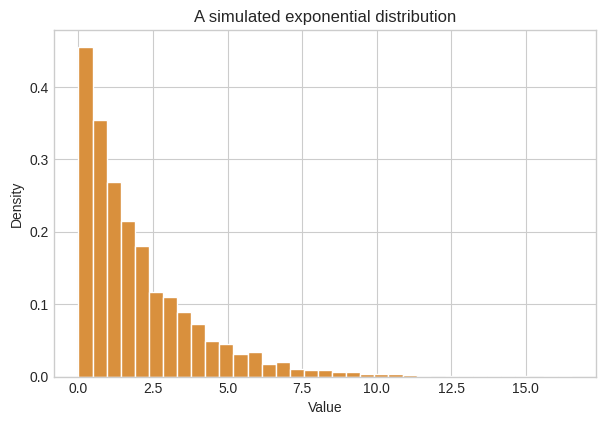

In [5]:
# Draw 5,000 waiting times with an average value of 2.
exponential = rng.exponential(scale=2, size=5_000)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(exponential, bins=35, density=True, color="#d9903d", edgecolor="white")
ax.set(title="A simulated exponential distribution", xlabel="Value", ylabel="Density")
plt.show()
#rng.exponential(...)：生成符合指数分布的随机样本。scale=2：参数 $\beta = 2$（代表平均间隔时间/期望值 $\mu = 2$；对应的率参数 $\lambda = \frac{1}{\text{scale}} = 0.5$）。size=5_000：抽样数量为 5,000 个数据点。

## Check-in

1. Which simulated distribution is symmetric? Which is right-skewed?
2. In `rng.normal(loc, scale, size)`, what does each argument control?
3. Give one setting in which a uniform distribution would be a reasonable model, and one in which it would not.

Keep your answers in your own notes. Bring your questions about these distributions and the CLT to class.

[Return to the Foundations page](index.qmd)